In [1]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

credit_approval = fetch_ucirepo(id=27)

X = credit_approval.data.features
y = credit_approval.data.targets

df = pd.concat([X, y], axis=1)

print(df.head())
print(df.shape)
print(df.info())

ModuleNotFoundError: No module named 'ucimlrepo'

In [2]:
!pip3 install ucimlrepo pandas numpy scikit-learn matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 4.1 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 22.2 MB/s eta 0:00:01
     |████████████████████████████████| 294 kB 16.9 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 13.0 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 18.4 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 26.9 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 13.3 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 19.2 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 18.9 MB/s eta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [3]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

credit_approval = fetch_ucirepo(id=27)

X = credit_approval.data.features
y = credit_approval.data.targets

df = pd.concat([X, y], axis=1)

print(df.head())
print(df.shape)
print(df.info())

   A15    A14 A13 A12  A11 A10 A9    A8 A7 A6 A5 A4     A3     A2 A1 A16
0    0  202.0   g   f    1   t  t  1.25  v  w  g  u  0.000  30.83  b   +
1  560   43.0   g   f    6   t  t  3.04  h  q  g  u  4.460  58.67  a   +
2  824  280.0   g   f    0   f  t  1.50  h  q  g  u  0.500  24.50  a   +
3    3  100.0   g   t    5   t  t  3.75  v  w  g  u  1.540  27.83  b   +
4    0  120.0   s   f    0   f  t  1.71  v  w  g  u  5.625  20.17  b   +
(690, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A15     690 non-null    int64  
 1   A14     677 non-null    float64
 2   A13     690 non-null    object 
 3   A12     690 non-null    object 
 4   A11     690 non-null    int64  
 5   A10     690 non-null    object 
 6   A9      690 non-null    object 
 7   A8      690 non-null    float64
 8   A7      681 non-null    object 
 9   A6      681 non-null    object 
 10

In [4]:
# Replace '?' with NaN
df = df.replace("?", np.nan)

# Check missing values
print(df.isnull().sum())

A15     0
A14    13
A13     0
A12     0
A11     0
A10     0
A9      0
A8      0
A7      9
A6      9
A5      6
A4      6
A3      0
A2     12
A1     12
A16     0
dtype: int64


In [7]:
# Rename columns first (important)
df.columns = [
    "A1","A2","A3","A4","A5","A6","A7","A8",
    "A9","A10","A11","A12","A13","A14","A15","target"
]

# Convert target
df["target"] = df["target"].map({"+": 1, "-": 0})

print(df["target"].value_counts())

target
0    383
1    307
Name: count, dtype: int64


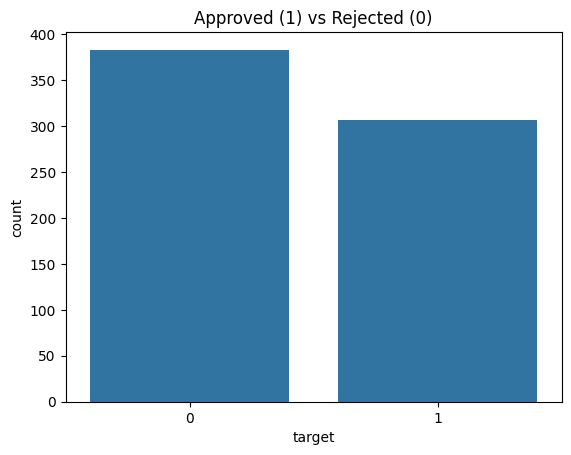

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Approved (1) vs Rejected (0)")
plt.show()

In [11]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)

Categorical columns: ['A3', 'A4', 'A6', 'A7', 'A9', 'A10', 'A11', 'A12', 'A15']


In [12]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.head())
print(df_encoded.shape)

    A1     A2  A5    A8    A13    A14  target   A3_p   A3_s   A4_t  ...  \
0    0  202.0   1  1.25  0.000  30.83       1  False  False  False  ...   
1  560   43.0   6  3.04  4.460  58.67       1  False  False  False  ...   
2  824  280.0   0  1.50  0.500  24.50       1  False  False  False  ...   
3    3  100.0   5  3.75  1.540  27.83       1  False  False   True  ...   
4    0  120.0   0  1.71  5.625  20.17       1  False   True  False  ...   

   A10_m  A10_q  A10_r  A10_w  A10_x  A11_gg  A11_p  A12_u  A12_y  A15_b  
0  False  False  False   True  False   False  False   True  False   True  
1  False   True  False  False  False   False  False   True  False  False  
2  False   True  False  False  False   False  False   True  False  False  
3  False  False  False   True  False   False  False   True  False   True  
4  False  False  False   True  False   False  False   True  False   True  

[5 rows x 38 columns]
(690, 38)


In [13]:
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

print(X.shape, y.shape)

(690, 37) (690,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)

(552, 37) (138, 37)


In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [20]:
y_pred = model.predict(X_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8623188405797102
              precision    recall  f1-score   support

           0       0.88      0.87      0.88        77
           1       0.84      0.85      0.85        61

    accuracy                           0.86       138
   macro avg       0.86      0.86      0.86       138
weighted avg       0.86      0.86      0.86       138

